In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'English Lab Presentation-1.pptx', 'English Lab Presentation.pptx', 'APTOS']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/APTOS"))

['aptos2019-blindness-detection.zip', 'aptos']


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/APTOS/aptos2019-blindness-detection.zip"
extract_path = "/content/APTOS"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ APTOS dataset extracted successfully!")

✅ APTOS dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/APTOS"))

['test_images', 'train.csv', 'test.csv', 'sample_submission.csv', 'train_images']


In [ ]:
import pandas as pd

train_csv = "/content/APTOS/train.csv"

df = pd.read_csv(train_csv)

print(df.head())
print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nLabel distribution:")
print(df["diagnosis"].value_counts().sort_index())

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Dataset shape: (3662, 2)

Columns: ['id_code', 'diagnosis']

Label distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["diagnosis"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(train_df["diagnosis"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["diagnosis"].value_counts().sort_index())

Training images: 2929
Validation images: 733

Training distribution:
diagnosis
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

Validation distribution:
diagnosis
0    361
1     74
2    200
3     39
4     59
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory="/content/APTOS/train_images",
    x_col="id_code",
    y_col="diagnosis",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    directory="/content/APTOS/train_images",
    x_col="id_code",
    y_col="diagnosis",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("✅ Data generators created successfully!")

Found 2929 validated image filenames belonging to 5 classes.
Found 733 validated image filenames belonging to 5 classes.
✅ Data generators created successfully!


In [ ]:
train_df["diagnosis"] = train_df["diagnosis"].astype(str)
val_df["diagnosis"] = val_df["diagnosis"].astype(str)

print(train_df.dtypes)
print(val_df.dtypes)

id_code      object
diagnosis    object
dtype: object
id_code      object
diagnosis    object
dtype: object


In [ ]:
train_df["id_code"] = train_df["id_code"].astype(str) + ".png"
val_df["id_code"] = val_df["id_code"].astype(str) + ".png"

print(train_df.head())

               id_code diagnosis
2579  b2b79b37d314.png         0
309   175dd560810a.png         2
2826  c3cd0200df79.png         3
2989  cfed7c1172ec.png         0
3344  e811f39a1243.png         2


In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("✅ ResNet50 loaded successfully!")
print("Total layers:", len(base_model.layers))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ ResNet50 loaded successfully!
Total layers: 175


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(5, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["diagnosis"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["diagnosis"]
)

class_weights = dict(zip(classes, class_weights))

print("Class weights:")
print(class_weights)

Class weights:
{'0': np.float64(0.4056786703601108), '1': np.float64(1.979054054054054), '2': np.float64(0.7331664580725907), '3': np.float64(3.803896103896104), '4': np.float64(2.4822033898305085)}


In [ ]:
history = model.fit(
    train_generator,
    validation_datatrg =val_generator,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 631s 7s/step - accuracy: 0.6436 - loss: 1.0878 - val_accuracy: 0.7231 - val_loss: 0.8335
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 698s 7s/step - accuracy: 0.7211 - loss: 0.7716 - val_accuracy: 0.7394 - val_loss: 0.7626
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 645s 7s/step - accuracy: 0.7456 - loss: 0.6835 - val_accuracy: 0.7558 - val_loss: 0.7138
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 609s 7s/step - accuracy: 0.7631 - loss: 0.6341 - val_accuracy: 0.7572 - val_loss: 0.6480
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 606s 7s/step - accuracy: 0.7730 - loss: 0.6261 - val_accuracy: 0.7667 - val_loss: 0.6907
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 605s 7s/step - accuracy: 0.7808 - loss: 0.6028 - val_accuracy: 0.7722 - val_loss: 0.6455
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 613s 7s/step - accuracy: 0.7887 - loss: 0.5747 - val_accuracy: 0.7763 - val_loss: 0.6608
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 608s 7s/step - accuracy: 0.7849 - loss: 0.5711 - val_accuracy: 0.7667 - v

In [ ]:
model.save("/content/DR_ResNet50_v1.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions on validation data
val_generator.reset()

predictions = model.predict(val_generator)

# Convert probabilities to class numbers
predicted_classes = np.argmax(predictions, axis=1)

# Actual class numbers
true_classes = val_generator.classes

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

print("Classification Report:")
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 118s 5s/step
Classification Report:
                  precision    recall  f1-score   support

           No DR       0.93      0.96      0.94       361
            Mild       0.53      0.36      0.43        74
        Moderate       0.65      0.90      0.76       200
          Severe       0.82      0.23      0.36        39
Proliferative DR       0.62      0.25      0.36        59

        accuracy                           0.79       733
       macro avg       0.71      0.54      0.57       733
    weighted avg       0.78      0.79      0.76       733



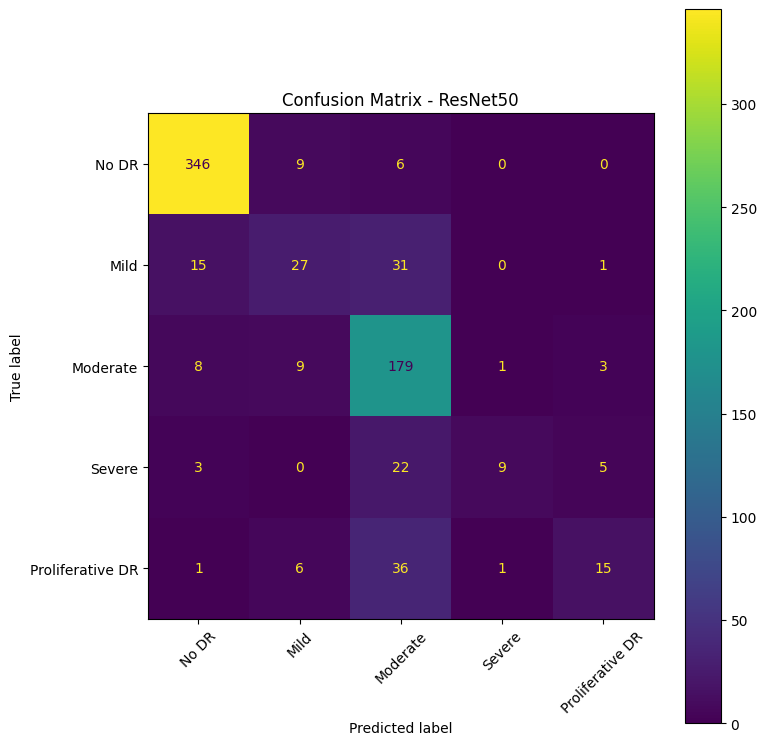

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - ResNet50")
plt.tight_layout()
plt.show()

In [ ]:
# Unfreeze the last 20 layers of ResNet50
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Total ResNet50 layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total ResNet50 layers: 175
Trainable layers: 20


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model recompiled for fine-tuning!")

✅ Model recompiled for fine-tuning!


In [ ]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    class_weight=class_weights
)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 734s 8s/step - accuracy: 0.7678 - loss: 0.6442 - val_accuracy: 0.7640 - val_loss: 0.6962
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 718s 8s/step - accuracy: 0.8074 - loss: 0.5318 - val_accuracy: 0.7817 - val_loss: 0.6599
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 712s 8s/step - accuracy: 0.8105 - loss: 0.5082 - val_accuracy: 0.7899 - val_loss: 0.6368


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

val_generator.reset()

predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

print("Classification Report:")
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 126s 5s/step
Classification Report:
                  precision    recall  f1-score   support

           No DR       0.93      0.96      0.95       361
            Mild       0.49      0.47      0.48        74
        Moderate       0.70      0.83      0.76       200
          Severe       0.62      0.33      0.43        39
Proliferative DR       0.58      0.32      0.41        59

        accuracy                           0.79       733
       macro avg       0.66      0.58      0.61       733
    weighted avg       0.78      0.79      0.78       733



In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[345  11   5   0   0]
 [ 12  35  25   1   1]
 [  7  18 167   3   5]
 [  3   0  15  13   8]
 [  2   7  27   4  19]]


In [ ]:
final_model_path = "/content/drive/MyDrive/DR_ResNet50_Final.keras"

model.save(final_model_path)

print("✅ Final ResNet50 model saved to Google Drive!")
print(final_model_path)

✅ Final ResNet50 model saved to Google Drive!
/content/drive/MyDrive/DR_ResNet50_Final.keras


In [ ]:
import random
import os

# Pick a random retinal image
image_name = random.choice(os.listdir("/content/APTOS/train_images"))
image_path = "/content/APTOS/train_images/" + image_name

print("Testing image:", image_name)
print("Image path:", image_path)

Testing image: cd45bfa07d41.png
Image path: /content/APTOS/train_images/cd45bfa07d41.png


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load and prepare the image
img = image.load_img(image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# ResNet50 preprocessing
from tensorflow.keras.applications.resnet50 import preprocess_input
img_array = preprocess_input(img_array)

# Prediction
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction[0])

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

confidence = prediction[0][predicted_class] * 100

print("================================")
print("🤖 DR MODEL PREDICTION")
print("================================")
print("Image:", image_name)
print("Predicted stage:", class_names[predicted_class])
print("Confidence:", round(confidence, 2), "%")
print("================================")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
🤖 DR MODEL PREDICTION
Image: cd45bfa07d41.png
Predicted stage: Mild
Confidence: 61.48 %


In [ ]:
# Find the actual APTOS label
actual_label = train_df[
    train_df["id_code"].str.replace(".png", "", regex=False) == "cd45bfa07d41"
]["diagnosis"].iloc[0]

label_names = {
    "0": "No DR",
    "1": "Mild",
    "2": "Moderate",
    "3": "Severe",
    "4": "Proliferative DR"
}

print("================================")
print("🔍 ACTUAL APTOS LABEL")
print("================================")
print("Actual stage:", label_names[str(actual_label)])
print("================================")

🔍 ACTUAL APTOS LABEL
Actual stage: Mild


In [ ]:
# Test the model on 20 validation images

val_generator.reset()

predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes

# Check first 20 predictions
correct = 0

print("================================")
print("🤖 MULTIPLE IMAGE TEST")
print("================================")

for i in range(20):
    actual = class_names[true_classes[i]]
    predicted = class_names[predicted_classes[i]]

    if true_classes[i] == predicted_classes[i]:
        correct += 1
        result = "✅ Correct"
    else:
        result = "❌ Wrong"

    print(f"{i+1}. Actual: {actual} | Predicted: {predicted} | {result}")

print("================================")
print("Correct:", correct, "out of 20")
print("Test accuracy:", round(correct / 20 * 100, 2), "%")
print("================================")

23/23 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step
🤖 MULTIPLE IMAGE TEST
1. Actual: No DR | Predicted: No DR | ✅ Correct
2. Actual: No DR | Predicted: No DR | ✅ Correct
3. Actual: Proliferative DR | Predicted: Moderate | ❌ Wrong
4. Actual: No DR | Predicted: No DR | ✅ Correct
5. Actual: No DR | Predicted: No DR | ✅ Correct
6. Actual: No DR | Predicted: No DR | ✅ Correct
7. Actual: Moderate | Predicted: Moderate | ✅ Correct
8. Actual: Severe | Predicted: Severe | ✅ Correct
9. Actual: Moderate | Predicted: Moderate | ✅ Correct
10. Actual: Mild | Predicted: Moderate | ❌ Wrong
11. Actual: No DR | Predicted: No DR | ✅ Correct
12. Actual: No DR | Predicted: No DR | ✅ Correct
13. Actual: No DR | Predicted: No DR | ✅ Correct
14. Actual: Mild | Predicted: No DR | ❌ Wrong
15. Actual: No DR | Predicted: No DR | ✅ Correct
16. Actual: No DR | Predicted: No DR | ✅ Correct
17. Actual: No DR | Predicted: No DR | ✅ Correct
18. Actual: No DR | Predicted: No DR | ✅ Correct
19. Actual: No DR | Predicted: No DR | ✅ C

In [ ]:
# Find the last convolutional layer

for layer in reversed(base_model.layers):
    if "conv" in layer.name.lower():
        print("Last convolutional layer:", layer.name)
        break

Last convolutional layer: conv5_block3_out


In [ ]:
import json

model_info = {
    "model": "ResNet50",
    "input_size": "224x224x3",
    "classes": [
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative DR"
    ],
    "last_conv_layer": "conv5_block3_out",
    "validation_accuracy": 0.7899,
    "macro_f1": 0.61
}

info_path = "/content/drive/MyDrive/DR_ResNet50_Model_Info.json"

with open(info_path, "w") as f:
    json.dump(model_info, f, indent=4)

print("✅ Model information saved to Google Drive!")
print(info_path)

✅ Model information saved to Google Drive!
/content/drive/MyDrive/DR_ResNet50_Model_Info.json


In [1]:
import tensorflow as tf

model_path = "/content/drive/MyDrive/DR_ResNet50_Final.keras"

model = tf.keras.models.load_model(model_path)

print("✅ Final model loaded successfully!")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

ValueError: File not found: filepath=/content/drive/MyDrive/DR_ResNet50_Final.keras. Please ensure the file is an accessible `.keras` zip file.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'English Lab Presentation-1.pptx', 'English Lab Presentation.pptx', 'APTOS', 'DR_ResNet50_Final.keras', 'SIH26038_DR_ResNet50_CoreML_GradCAM.ipynb']


In [4]:
import tensorflow as tf

model_path = "/content/drive/MyDrive/DR_ResNet50_Final.keras"

model = tf.keras.models.load_model(model_path)

print("✅ Final model loaded successfully!")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

✅ Final model loaded successfully!
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 5)


In [5]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create a model that gives both:
    # 1. Last convolutional layer output
    # 2. Final prediction
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer("resnet50").get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class]

    # Calculate gradients
    grads = tape.gradient(class_score, conv_outputs)

    # Average gradients over height and width
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

    # Weight the feature maps
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.maximum(tf.reduce_max(heatmap), 1e-8)

    return heatmap.numpy()

print("✅ Grad-CAM function created successfully!")

✅ Grad-CAM function created successfully!


In [6]:
# Load the retinal image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

img_path = "/content/APTOS/train_images/cd45bfa07d41.png"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Generate Grad-CAM heatmap
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    "conv5_block3_out"
)

print("✅ Grad-CAM heatmap generated!")
print("Heatmap shape:", heatmap.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/APTOS/train_images/cd45bfa07d41.png'

In [7]:
import os

print(os.listdir("/content/drive/MyDrive/APTOS"))

['aptos2019-blindness-detection.zip', 'aptos']


In [8]:
import os

print(os.listdir("/content/drive/MyDrive/APTOS/aptos"))

['test.csv', 'sample_submission.csv', 'train.csv', 'train_images', 'test_images']


In [9]:
import os

img_path = "/content/drive/MyDrive/APTOS/aptos/train_images/cd45bfa07d41.png"

print("Image exists:", os.path.exists(img_path))
print("Image path:", img_path)

Image exists: False
Image path: /content/drive/MyDrive/APTOS/aptos/train_images/cd45bfa07d41.png


In [10]:
import os

train_path = "/content/drive/MyDrive/APTOS/aptos/train_images"

images = [
    f for f in os.listdir(train_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Number of training images:", len(images))
print("First 5 images:", images[:5])

Number of training images: 1208
First 5 images: ['32d7d360d891.png', '33b91def2035.png', '3325b1fe55d2.png', '32ed318235b8.png', '342edf9b889d.png']


In [11]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

img_path = "/content/drive/MyDrive/APTOS/aptos/train_images/32d7d360d891.png"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Generate Grad-CAM
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    "conv5_block3_out"
)

print("✅ Grad-CAM heatmap generated!")
print("Heatmap shape:", heatmap.shape)

AttributeError: The layer sequential has never been called and thus has no defined output.

In [12]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Get the ResNet50 base model
    base_model = model.get_layer("resnet50")

    # Create a model for Grad-CAM
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_output = grad_model(img_array, training=False)

        # Pass through the remaining layers of our model
        x = base_output
        x = model.get_layer("global_average_pooling2d")(x)
        x = model.get_layer("dropout")(x, training=False)
        predictions = model.get_layer("dense")(x)

        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class]

    # Calculate gradients
    grads = tape.gradient(class_score, conv_outputs)

    # Average gradients
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.maximum(tf.reduce_max(heatmap), 1e-8)

    return heatmap.numpy()

print("✅ Corrected Grad-CAM function created!")

✅ Corrected Grad-CAM function created!


In [13]:
# Generate Grad-CAM for the selected retinal image

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    "conv5_block3_out"
)

print("✅ Grad-CAM heatmap generated!")
print("Heatmap shape:", heatmap.shape)

✅ Grad-CAM heatmap generated!
Heatmap shape: (7, 7)


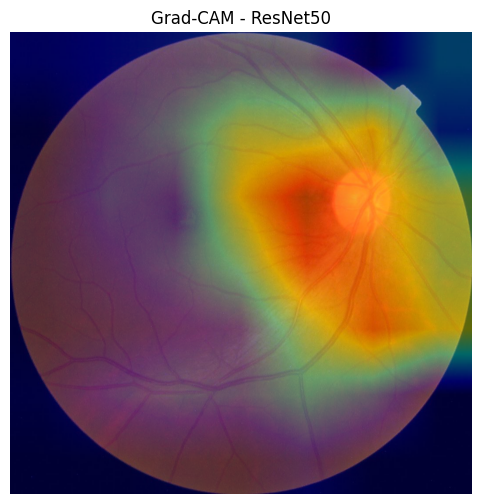

In [14]:
import matplotlib.pyplot as plt
import cv2

# Load original image
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Resize heatmap to original image size
heatmap_resized = cv2.resize(
    heatmap,
    (original_img.shape[1], original_img.shape[0])
)

# Convert heatmap to color
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay heatmap on original image
overlay = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(10, 6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM - ResNet50")
plt.show()

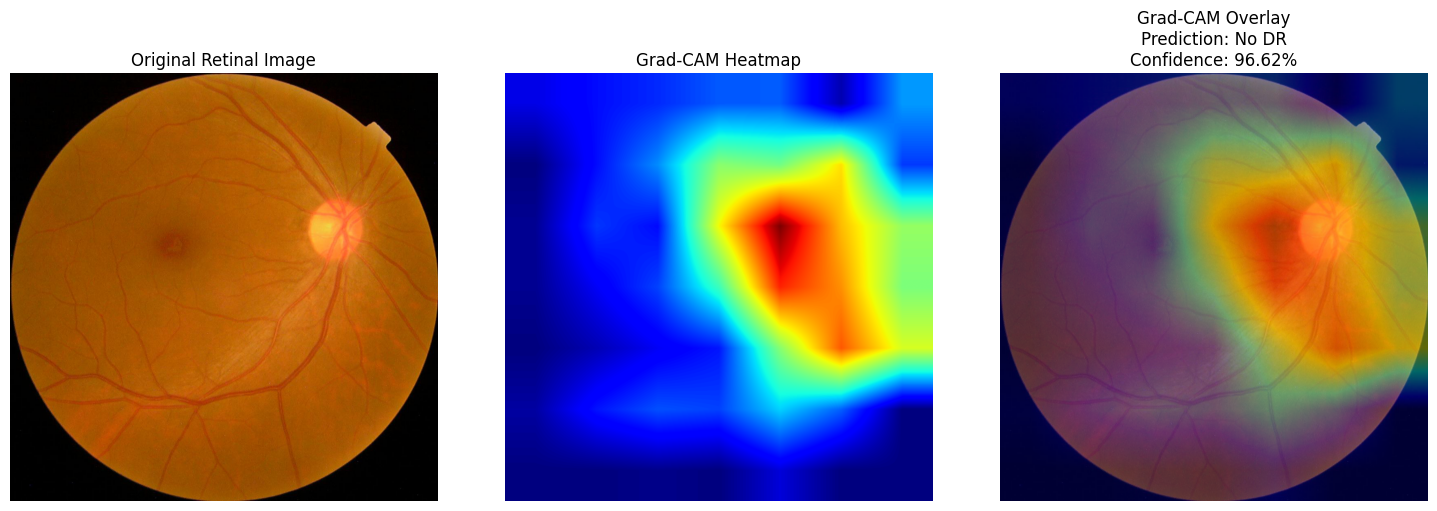

In [15]:
import matplotlib.pyplot as plt
import cv2

# Load original image
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Resize heatmap
heatmap_resized = cv2.resize(
    heatmap,
    (original_img.shape[1], original_img.shape[0])
)

# Create colored heatmap
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Create overlay
overlay = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Get prediction
predictions = model.predict(img_array, verbose=0)
predicted_class = np.argmax(predictions[0])
confidence = predictions[0][predicted_class] * 100

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

# Show all three
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Retinal Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Grad-CAM Overlay\n"
    f"Prediction: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Save the Grad-CAM visualization to Google Drive

output_path = "/content/drive/MyDrive/GradCAM_Result_32d7d360d891.png"

plt.savefig(output_path, bbox_inches="tight", dpi=300)

print("✅ Grad-CAM result saved successfully!")
print(output_path
      )

✅ Grad-CAM result saved successfully!
/content/drive/MyDrive/GradCAM_Result_32d7d360d891.png


<Figure size 640x480 with 0 Axes>

In [17]:
import pandas as pd
import os

# Load APTOS training labels
csv_path = "/content/drive/MyDrive/APTOS/aptos/train.csv"
train_path = "/content/drive/MyDrive/APTOS/aptos/train_images"

df = pd.read_csv(csv_path)

# Add .png to image IDs
df["filename"] = df["id_code"].astype(str) + ".png"

# Find Moderate DR images that actually exist in our folder
moderate_images = df[
    (df["diagnosis"] == 2) &
    (df["filename"].apply(lambda x: os.path.exists(os.path.join(train_path, x))))
]

print("Moderate DR images available:", len(moderate_images))
print("Selected image:", moderate_images.iloc[0]["filename"])

Moderate DR images available: 96
Selected image: 0180bfa26c0b.png


In [18]:
# Moderate DR image for Grad-CAM

img_path = "/content/drive/MyDrive/APTOS/aptos/train_images/0180bfa26c0b.png"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Generate Grad-CAM
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    "conv5_block3_out"
)

print("✅ Moderate DR Grad-CAM generated!")
print("Heatmap shape:", heatmap.shape)

✅ Moderate DR Grad-CAM generated!
Heatmap shape: (7, 7)


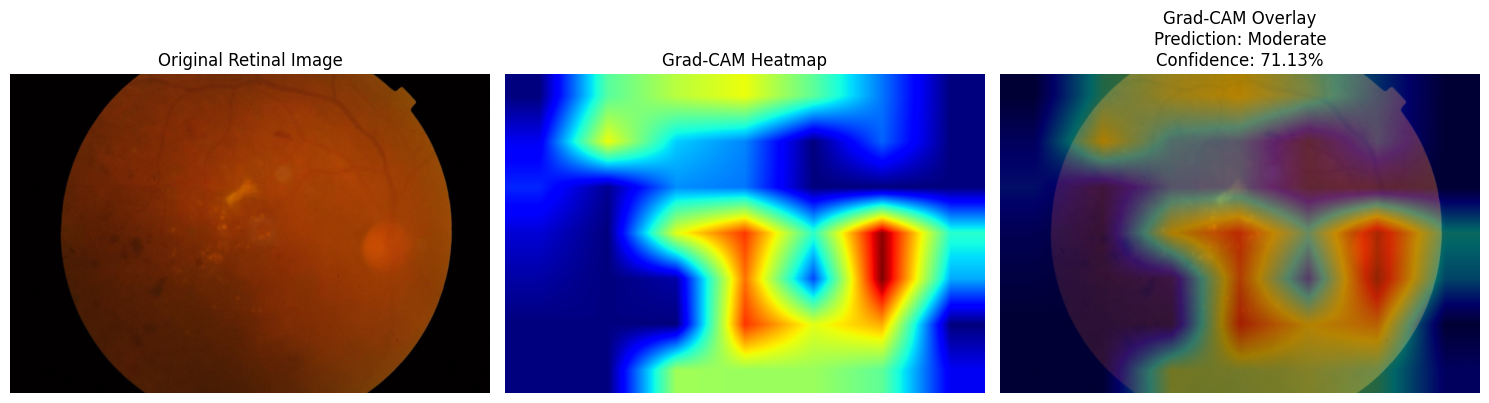

Actual APTOS stage: Moderate
Model prediction: Moderate
Confidence: 71.13%


In [19]:
import matplotlib.pyplot as plt
import cv2

# Load original image
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Resize heatmap
heatmap_resized = cv2.resize(
    heatmap,
    (original_img.shape[1], original_img.shape[0])
)

# Create colored heatmap
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Create overlay
overlay = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Get prediction
predictions = model.predict(img_array, verbose=0)
predicted_class = np.argmax(predictions[0])
confidence = predictions[0][predicted_class] * 100

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Retinal Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Grad-CAM Overlay\n"
    f"Prediction: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.show()

print("Actual APTOS stage: Moderate")
print("Model prediction:", class_names[predicted_class])
print(f"Confidence: {confidence:.2f}%")

In [20]:
# Lesion / feature comparison report

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

predictions = model.predict(img_array, verbose=0)
predicted_class = np.argmax(predictions[0])
confidence = predictions[0][predicted_class] * 100

actual_stage = "Moderate"

print("==============================================")
print("       EXPLAINABILITY / LESION COMPARISON")
print("==============================================")
print("Image:", os.path.basename(img_path))
print("Actual APTOS stage:", actual_stage)
print("Model prediction:", class_names[predicted_class])
print(f"Confidence: {confidence:.2f}%")
print("----------------------------------------------")
print("Grad-CAM layer: conv5_block3_out")
print("Heatmap size:", heatmap.shape)
print("----------------------------------------------")
print("Observation:")
print("The Grad-CAM highlights retinal regions that")
print("contributed strongly to the model prediction.")
print()
print("The highlighted regions should be visually")
print("compared with retinal abnormalities such as")
print("microaneurysms, hemorrhages and exudates.")
print()
print("Note: Grad-CAM shows model attention and does")
print("not independently confirm a specific lesion.")
print("==============================================")

       EXPLAINABILITY / LESION COMPARISON
Image: 0180bfa26c0b.png
Actual APTOS stage: Moderate
Model prediction: Moderate
Confidence: 71.13%
----------------------------------------------
Grad-CAM layer: conv5_block3_out
Heatmap size: (7, 7)
----------------------------------------------
Observation:
The Grad-CAM highlights retinal regions that
contributed strongly to the model prediction.

The highlighted regions should be visually
compared with retinal abnormalities such as
microaneurysms, hemorrhages and exudates.

Note: Grad-CAM shows model attention and does
not independently confirm a specific lesion.


In [21]:
# AI Explanation Generation

stage = class_names[predicted_class]

print("==============================================")
print("          🤖 AI EXPLANATION")
print("==============================================")
print(f"Predicted DR Stage : {stage}")
print(f"Confidence         : {confidence:.2f}%")
print("----------------------------------------------")

if stage == "No DR":
    explanation = (
        "The model predicts No Diabetic Retinopathy. "
        "The Grad-CAM highlights the retinal regions "
        "that contributed most to this decision."
    )

elif stage == "Mild":
    explanation = (
        "The model predicts Mild Diabetic Retinopathy. "
        "The Grad-CAM highlights regions that influenced "
        "the model's decision and can be reviewed for "
        "early retinal abnormalities."
    )

elif stage == "Moderate":
    explanation = (
        "The model predicts Moderate Diabetic Retinopathy. "
        "The Grad-CAM highlights retinal regions that "
        "contributed strongly to this prediction. "
        "These regions can be visually compared with "
        "DR-related features such as microaneurysms, "
        "hemorrhages and exudates."
    )

elif stage == "Severe":
    explanation = (
        "The model predicts Severe Diabetic Retinopathy. "
        "The Grad-CAM highlights retinal regions that "
        "strongly influenced the prediction and can be "
        "reviewed for visible retinal abnormalities."
    )

else:
    explanation = (
        "The model predicts Proliferative Diabetic Retinopathy. "
        "The Grad-CAM highlights regions that contributed "
        "strongly to the prediction and can be reviewed "
        "for abnormal retinal features and vessel changes."
    )

print("Explanation:")
print(explanation)
print("----------------------------------------------")
print("⚠️ Grad-CAM indicates model attention and does")
print("not independently confirm a specific lesion.")
print("==============================================")

          🤖 AI EXPLANATION
Predicted DR Stage : Moderate
Confidence         : 71.13%
----------------------------------------------
Explanation:
The model predicts Moderate Diabetic Retinopathy. The Grad-CAM highlights retinal regions that contributed strongly to this prediction. These regions can be visually compared with DR-related features such as microaneurysms, hemorrhages and exudates.
----------------------------------------------
⚠️ Grad-CAM indicates model attention and does
not independently confirm a specific lesion.


In [22]:
# Save Grad-CAM result to Google Drive

gradcam_path = "/content/drive/MyDrive/GradCAM_Moderate_0180bfa26c0b.png"

plt.savefig(gradcam_path, bbox_inches="tight", dpi=300)

print("✅ Grad-CAM image saved!")
print(gradcam_path)

✅ Grad-CAM image saved!
/content/drive/MyDrive/GradCAM_Moderate_0180bfa26c0b.png


<Figure size 640x480 with 0 Axes>

In [23]:
# Save AI explanation to Google Drive

explanation_path = "/content/drive/MyDrive/AI_Explanation_Moderate_0180bfa26c0b.txt"

with open(explanation_path, "w") as f:
    f.write("AI EXPLANATION - DIABETIC RETINOPATHY\n")
    f.write("=====================================\n")
    f.write(f"Image: 0180bfa26c0b.png\n")
    f.write("Actual Stage: Moderate\n")
    f.write(f"Predicted Stage: {stage}\n")
    f.write(f"Confidence: {confidence:.2f}%\n\n")
    f.write("Explanation:\n")
    f.write(explanation + "\n\n")
    f.write("Note: Grad-CAM indicates model attention and does not independently confirm a specific lesion.\n")

print("✅ AI explanation saved!")
print(explanation_path)

✅ AI explanation saved!
/content/drive/MyDrive/AI_Explanation_Moderate_0180bfa26c0b.txt
